# Sensors and Signal Analysis 2026
Author: Nuno Azevedo Silva, Catarina Monteiro

### Hands-on activity 3

This notebook supports the second Hands-on activity where the students will explore 3 optical phenomena and how these can be used to

1. Polarization-based sensing;
2. Young Double Slit - Explore the emergence of the fringes and their position, how these can be explored as a sensor;


The idea is that you get familiarized with the interference of waves, what can you sense, and how you interrogate it as a sensor.

## 1. Polarization-based sensing

This second experiment studies how mechanical perturbations affect the state of polarization (SOP) in an optical fiber and how these changes can be measured as intensity variations using a Polarizing Beam Splitter (PBS). Light propagates through a single-mode fiber (SMF), where its polarization is not preserved. Mechanical perturbations—such as bending or vibration—change the fiber birefringence, causing the SOP to vary over time. At the PBS, the incoming light is split into two orthogonal polarization components. As the SOP changes, the power distribution between these outputs also changes, converting polarization fluctuations into intensity variations. A piezoelectric actuator is used to apply controlled perturbations to the fiber, and the resulting intensity signal is measured with a photodetector. 

This setup enables controlled analysis of polarization dynamics in optical fibers and serves as a basis for sensing applications where external perturbations are encoded in polarization changes.

<img src="Figures/setup_polarization.png" width="600"/>

## 1.1 Characterize the sensor

Using the applied peak-to-peak voltage (related with deformation) as the stimuli, characterize your sensor for a fixed frequency by varying the input peak-to-peak value. This will allow you to determine amongst others:
 - span
 - full-scale output
 - dynamic range
 - deadband/saturation (if exists)
 - hysterisis
 - repeatability
 - sensitivity
 - SNR

Take 10 points and sketch a transfer function for this sensor. Given the limited time, you don't need to consider the uncertainty for this problem.


In [4]:
## Use data aquired from the notebook provided

## applied_voltages = []
## p_at_f = []
## plot

## 1.2 Discussion 

a. Create a minimalistic model assuming only linear polarization states (obviously incomplete for a case of a fiber) and that the polarization state $\boldsymbol{e}_p = cos(\theta) \boldsymbol{x} + sin(\theta) \boldsymbol{y} $ changes from angle $\theta$ to $\theta+\delta \theta$ where $\delta \theta$ will ultimately be related with the applied voltage.

    a1. Compute the intensity in each of the arms and plot the change.

    a2. What is the sensitivity? What is the best operation point? How can you control that?
    
    a3. And the dynamic range?

b. Discuss three advantages of using a polarization-based fiber optic sensor for vibration monitoring along with two possible applications.


## 2. Young Double Slit

In the Young's Double Slit experiment we have a laser that is divided in two wavefronts by a double slit. Each of the slits will act as a cylindrical wave source, which will interfere at the observation plane. The temporal coherence (necessary for interference) is warranted by the wavefront division mechanism (the double slit) as long as the distance between the slits is below the spatial coherence length.

<center>
<img src="Figures/slit1.png" class="bg-primary" height="200px">
</center>

In the lectures we derived an expression for the distance between consecutive fringes $\Delta y$ for $L>>d$ as

$\Delta y = \frac{\lambda L}{d} $

where $L$ is the distance between the slits and the observation plane, $\lambda$ the wavelength, and $d$ the distance of the slits.



## 2.1 Qualitative analysis;

a. Using the experimental setup we provided observe the double fringe emergence when using two slits vs no interference when using only one slit;

b. Observe qualitatively what happens if you increase the slit distance;

c. Using the microscope slide given and the linear stage, try to put it on the front of only one of the slits, and observe in the camera what happens.

    c1. Assuming a plane wave solution and neglecting reflections, demonstrate that if refractive index is $n$ and the thickness $Δl$, the interference pattern is given by 

$I=I_1+I_2+ 2√(I_1 I_2 ) cos⁡(k dy/L+2π/λ (n-1)Δl)$

    c2. One way to interrogate such a sensor would be to track the position of the first maximum. Compute the sensitivity and comment its dependence on L.

    c3. Compute the phase shift for a microscope slide (thickness 165 micrometers, n=1.55). Comment taking into consideration your observations.

d. Considering the dynamic range (Can you provide an estimate?) what would be a possible application for a sensor like this one?


## 2.2 Quantitative analysis: Measuring the wavelenght of a laser

In the laboratory we did the following experiment: a laser source (with a given wavelength, which will be varied) incident in a double slit ($d=0.05mm$) generates a fringe pattern which is imaged at the camera plane ($L=60cm$).

<center>
<img src="Figures/dslit.png" class="bg-primary" height="400px">
</center>

The obtained data is suplied in two images 'Laser1_doubleslit_d05mm_L60cm.png' and 'Laser2_doubleslit_d05mm_L60cm.png' containing distinc images taken by the camera C1 for two distinct wavelengths.

1. Estimate the wavelenght of the laser by fitting the data;
2. How could you utilize the double slit configuration as a sensor?

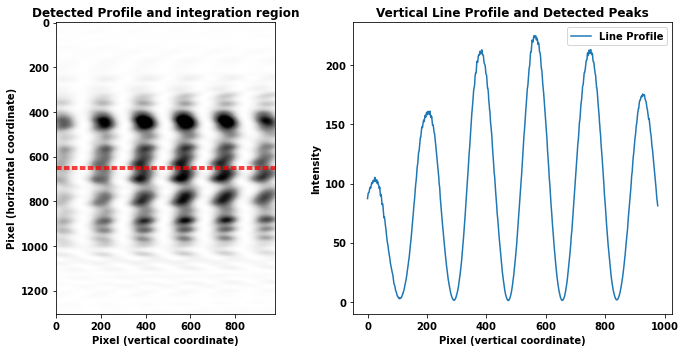

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

###Read Data 

image_path    = 'double_slit//Laser2_doubleslit_d05mm_L60cm.png'     # Image filename - there are two figures, Laser1_... and Laser2_...
pixel_pitch   = 3.45e-6         # 3.45 micrometers in meters
L             = 0.60            # Distance from slits to camera [m]
d             = 0.50e-3         # Slit separation [m]
x_center      = 0               # "Center column" for your line profile (pixels) - you can choose this
profile_width = 10             # How many columns to average over (pixels)

# --- 1. Load image (grayscale) ---
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
img_f = img.astype(np.float64)

# Get image dimensions
height, width = img_f.shape

# We will divide it at center and integrate a width corresponding to the profile_width in pixels defined above
center_col = width // 2 + x_center

col_start = center_col - profile_width // 2
col_end   = center_col + profile_width // 2

# --- 2. Extract and average vertical line profile around x=0 ---
line_profile = np.mean(img_f[:, col_start:col_end], axis=1)


# --- 3. Display the results ---
fig, ax = plt.subplots(1,2, figsize=[10,5])

ax[0].imshow(np.transpose(img_f), cmap='Greys')
ax[0].axhline(col_start, ls='--', color='r')
ax[0].axhline(col_end, ls='--', color='r')
ax[0].set_xlabel('Pixel (vertical coordinate)')
ax[0].set_ylabel('Pixel (horizontal coordinate)')
ax[0].set_title('Detected Profile and integration region')


ax[1].plot(line_profile, label='Line Profile')
ax[1].set_xlabel('Pixel (vertical coordinate)')
ax[1].set_ylabel('Intensity')
ax[1].legend()
ax[1].set_title('Vertical Line Profile and Detected Peaks')
fig.tight_layout()



In [2]:

# --- 4. Find peaks in the line profile after applying a moving mean to smooth data --- and display the results

# --- 5. Measure the fringe spacing in pixels and use the double-slit formula: lambda = (Delta y * d) / L ---

# Convert that spacing to meters using the pixel pitch and:

# Delta y = avg fringe spacing on the screen
# d = slit separation, L = distance from slits to camera

# Convert to nanometers for a more typical scale: